In [155]:
import pandas as pd
import numpy as np
import math
from surprise import Dataset, Reader, SVD, accuracy
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import random
import matplotlib.pyplot as plt
import tf2onnx
import onnx
import onnxruntime as ort
import os

# Testdata, based on entity list provided by App4Sales

## Customers

In [ ]:
Address

  Guid Id
  String BackofficeId
  String AddressLine1
  String AddressLine2
  String AddressLine3
  String PostalCode
  String City
  String Country
  String CountryCode
  String State
  Guid CustomerGuid

In [ ]:
Customer

  Int32 Index
  String Name
  String ContactFullName

In [ ]:
## Example Address 
{
  "id": "3f1c2a9e-7b4c-4e8d-9b21-6a0f9e4c1234",
  "backofficeId": "BO-ADDR-102938",
  "addressLine1": "Damrak 123",
  "addressLine2": "Apartment 4B",
  "addressLine3": "",
  "postalCode": "1012 LP",
  "city": "Amsterdam",
  "country": "Netherlands",
  "countryCode": "NL",
  "state": "Noord-Holland",
  "customerGuidCustomer": "8a7b6c5d-4e3f-42a1-9c88-123456789abc"
}

In [ ]:
# example customer
{
  "index": 1,
  "customerGuid": "8a7b6c5d-4e3f-42a1-9c88-123456789abc",
  "name": "Primary Contact",
  "contactFullName": "Lucas Hoek"
}

## Items

In [ ]:
Item

+Int32 Index
+String Unit
+Decimal LastAvailableStock
+String SearchDescription
+String ItemCode
+Decimal SalesPrice
+String CatalogDescription
+String Description
+Decimal MinimumOrderQuantity
+Boolean IsDeleted


In [ ]:
{
  "index": 1,
  "unit": "pcs",
  "lastAvailableStock": 125.50,
  "searchDescription": "Wireless ergonomic keyboard",
  "itemCode": "KB-WL-ERG-001",
  "salesPrice": 79.99,
  "catalogDescription": "Ergonomic Wireless Keyboard",
  "description": "A comfortable, wireless ergonomic keyboard suitable for daily office use.",
  "minimumOrderQuantity": 1,
  "isDeleted": false
}

In [ ]:
{
  "index": 1,
  "unit": "pcs",
  "lastAvailableStock": 125.50,
  "searchDescription": "Wired ergonomic keyboard",
  "ItemCode": "KB-WL-ERG-003",
  "salesPrice": 79.99,
  "catalogDescription": "Ergonomic Wired Keyboard",
  "description": "A comfortable, wired ergonomic keyboard suitable for daily office use.",
  "minimumOrderQuantity": 1,
  "isDeleted": false
}

In [ ]:
ItemClass

+Int32 Id
+String Description
+String ItemCode

SyntaxError: invalid syntax (3777300747.py, line 3)

In [ ]:

{
  "itemClassId": 10,
  "description": "Electronics Accessories",
  "itemCode": "KB-WL-ERG-001"
}


In [ ]:
ItemClassValue

+Int32 ItemClassId
+String Description
+Int32 Sequence

In [ ]:

{
  "itemClassId": 10,
  "description": "Electronics Accessories",
  "sequence": 1
}


In [ ]:
PriceList

+Int32 Id
+String Code
+String Description
+String Currency
+Boolean Selectable

In [ ]:
{
  "id": 1,
  "code": "EU-STD-2026",
  "description": "European Standard Price List 2026",
  "currency": "EUR",
  "selectable": true
}

## Order

In [ ]:
{
    "Id": 24862,
    "customerName": "John Doe",
    "customerGuid": "8a7b6c5d-4e3f-42a1-9c88-123456789abc",
    "orderDate": "2024-06-15T14:30:00Z",
    "orderType": "Standard",
    "Created" : "2024-06-15T14:30:00Z",
}

### orderlist

er

In [ ]:
{
    "Id": 24862,
    "ItemCode": "KB-WL-ERG-001",
    "quantity": 2
}

In [ ]:
{
    "Id": 24862,
    "ItemCode": "KB-WL-ERG-003",
    "quantity": 1
}

In [ ]:
# ------------------------------------------------------------
# ✅ 1. Test Data 
# ------------------------------------------------------------
test_data = {
    "Countries": [
        {"country_id": 1, "country_name": "Netherlands"},
        {"country_id": 2, "country_name": "Germany"},
        {"country_id": 3, "country_name": "Belgium"}
    ],

    "Customers": [
        {"customer_id": 1001, "addresses": "Fashion Store A", "country_id": 1},
        {"customer_id": 1002, "addresses": "Sneaker Shop B", "country_id": 2},
        {"customer_id": 1003, "addresses": "Urban Outfitters Plus", "country_id": 1},
        {"customer_id": 1004, "addresses": "Premium Streetwear Co", "country_id": 3},
        {"customer_id": 1005, "addresses": "Sporty Life Retail", "country_id": 2},
    ],

    # ---- ITEMS & CLASSES ----------------------------------------------------
    "Items": [
        {"item_id": 1, "name": "T-Shirt Basic", "class_id": 10},
        {"item_id": 2, "name": "Jeans Slim Fit", "class_id": 10},
        {"item_id": 3, "name": "Sneakers White", "class_id": 20},
        {"item_id": 4, "name": "Hoodie Oversized", "class_id": 10},
        {"item_id": 5, "name": "Running Shoes Pro", "class_id": 20},
        {"item_id": 6, "name": "Baseball Cap", "class_id": 30},
        {"item_id": 7, "name": "Leather Jacket", "class_id": 40},
        {"item_id": 8, "name": "Winter Coat", "class_id": 40},
        {"item_id": 9, "name": "Tank Top", "class_id": 10},
        {"item_id": 10, "name": "Cargo Pants", "class_id": 10},
        {"item_id": 11, "name": "High-Top Sneakers", "class_id": 20},
        {"item_id": 12, "name": "Slip-On Shoes", "class_id": 20},
        {"item_id": 13, "name": "Graphic Tee", "class_id": 10},
        {"item_id": 14, "name": "Track Jacket", "class_id": 40},
        {"item_id": 15, "name": "Sport Shorts", "class_id": 30},
    ],

    "ItemClasses": [
        {"class_id": 10, "class_name": "Clothing"},
        {"class_id": 20, "class_name": "Shoes"},
        {"class_id": 30, "class_name": "Accessories"},
        {"class_id": 40, "class_name": "Outerwear"}
    ],

    "ItemClassValues": [
        {"value_id": 101, "class_id": 10, "value_name": "Tops"},
        {"value_id": 102, "class_id": 10, "value_name": "Bottoms"},
        {"value_id": 103, "class_id": 10, "value_name": "Sportswear"},
        {"value_id": 201, "class_id": 20, "value_name": "Sneakers"},
        {"value_id": 202, "class_id": 20, "value_name": "Running Shoes"},
        {"value_id": 301, "class_id": 30, "value_name": "Headwear"},
        {"value_id": 401, "class_id": 40, "value_name": "Jackets"},
        {"value_id": 402, "class_id": 40, "value_name": "Coats"},
    ],

    # ---- VARIANTS ------------------------------------------------------------
    "MatrixHeaders": [
        {"matrix_id": 1, "header_name": "Color"},
        {"matrix_id": 2, "header_name": "Size"}
    ],

    "MatrixParents": [
        {"parent_id": 1, "item_id": 1},
        {"parent_id": 2, "item_id": 3},
        {"parent_id": 3, "item_id": 4},
    ],

    "MatrixChildren": [
        {"child_id": 1, "parent_id": 1, "variant_value": "Red"},
        {"child_id": 2, "parent_id": 1, "variant_value": "Blue"},
        {"child_id": 3, "parent_id": 2, "variant_value": "White"},
        {"child_id": 4, "parent_id": 2, "variant_value": "Black"},
        {"child_id": 5, "parent_id": 3, "variant_value": "Green"},
        {"child_id": 6, "parent_id": 3, "variant_value": "Beige"},
    ],

    # ---- FAVORITES -----------------------------------------------------------
    "UserFavoriteItems": [
        {"user_id": 501, "item_id": 1},
        {"user_id": 501, "item_id": 3},
        {"user_id": 501, "item_id": 7},

        {"user_id": 502, "item_id": 2},
        {"user_id": 502, "item_id": 8},

        {"user_id": 503, "item_id": 5},
        {"user_id": 503, "item_id": 11},
        {"user_id": 503, "item_id": 15},

        {"user_id": 504, "item_id": 6},
        {"user_id": 504, "item_id": 13},

        {"user_id": 505, "item_id": 1},
        {"user_id": 505, "item_id": 14},
    ],

    # ---- USERS ---------------------------------------------------------------
    "Users": [
        {"user_id": 501, "name": "SalesRep1"},
        {"user_id": 502, "name": "SalesRep2"},
        {"user_id": 503, "name": "SalesRep3"},
        {"user_id": 504, "name": "SalesRep4"},
        {"user_id": 505, "name": "SalesRep5"},
    ],

    "SalesReps": [
        {"salesrep_id": 501, "customer_id": 1001},
        {"salesrep_id": 502, "customer_id": 1002},
        {"salesrep_id": 503, "customer_id": 1003},
        {"salesrep_id": 504, "customer_id": 1004},
        {"salesrep_id": 505, "customer_id": 1005},
    ],

    # ---- ORDERS --------------------------------------------------------------
    "Orders": [
        {"order_id": 9001, "customer_id": 1001},
        {"order_id": 9002, "customer_id": 1002},
        {"order_id": 9003, "customer_id": 1001},
        {"order_id": 9004, "customer_id": 1004},
        {"order_id": 9005, "customer_id": 1003},
        {"order_id": 9006, "customer_id": 1005},
        {"order_id": 9007, "customer_id": 1002},
        {"order_id": 9008, "customer_id": 1003}
    ],

    "OrderLines": [
        {"orderline_id": 1, "order_id": 9001, "item_id": 1, "quantity": 3},
        {"orderline_id": 2, "order_id": 9001, "item_id": 2, "quantity": 1},

        {"orderline_id": 3, "order_id": 9002, "item_id": 3, "quantity": 2},
        {"orderline_id": 4, "order_id": 9002, "item_id": 7, "quantity": 1},

        {"orderline_id": 5, "order_id": 9003, "item_id": 4, "quantity": 4},
        {"orderline_id": 6, "order_id": 9003, "item_id": 10, "quantity": 2},

        {"orderline_id": 7, "order_id": 9004, "item_id": 11, "quantity": 1},
        {"orderline_id": 8, "order_id": 9004, "item_id": 12, "quantity": 2},

        {"orderline_id": 9, "order_id": 9005, "item_id": 5, "quantity": 3},
        {"orderline_id": 10, "order_id": 9005, "item_id": 15, "quantity": 2},

        {"orderline_id": 11, "order_id": 9006, "item_id": 9, "quantity": 1},
        {"orderline_id": 12, "order_id": 9006, "item_id": 1, "quantity": 2},

        {"orderline_id": 13, "order_id": 9007, "item_id": 13, "quantity": 1},
        {"orderline_id": 14, "order_id": 9007, "item_id": 3, "quantity": 1},

        {"orderline_id": 15, "order_id": 9008, "item_id": 8, "quantity": 2},
        {"orderline_id": 16, "order_id": 9008, "item_id": 12, "quantity": 3},
    ]
}

In [ ]:
# ============================================================
# 🔧 HELPER FUNCTION: Generate Synthetic Data at Scale
# ============================================================
def generate_app4sales_dataset(base_data, target_customers, target_items, target_categories, target_orders, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    scaled_data = {}
    scaled_data["Countries"] = [c.copy() for c in base_data["Countries"]]

    # Customers
    base_customers = base_data["Customers"]
    scaled_customers = []
    next_customer_id = 1001
    while len(scaled_customers) < target_customers:
        for cust in base_customers:
            if len(scaled_customers) >= target_customers:
                break
            new_cust = cust.copy()
            new_cust["customer_id"] = next_customer_id
            new_cust["addresses"] = f"{cust['addresses']} Clone {len(scaled_customers) // len(base_customers) + 1}"
            scaled_customers.append(new_cust)
            next_customer_id += 1
    scaled_data["Customers"] = scaled_customers

    # Item categories
    item_classes = []
    for class_idx in range(target_categories):
        item_classes.append({
            "class_id": 10 + class_idx,
            "class_name": f"Category {class_idx + 1}"
        })
    scaled_data["ItemClasses"] = item_classes

    # Item class values (3 values per category)
    item_class_values = []
    next_value_id = 100
    for category in item_classes:
        for value_idx in range(3):
            item_class_values.append({
                "value_id": next_value_id,
                "class_id": category["class_id"],
                "value_name": f"{category['class_name']} Value {value_idx + 1}"
            })
            next_value_id += 1
    scaled_data["ItemClassValues"] = item_class_values

    # Items
    base_items = base_data["Items"]
    scaled_items = []
    next_item_id = 1
    for item_idx in range(target_items):
        base_item = base_items[item_idx % len(base_items)]
        scaled_items.append({
            "item_id": next_item_id,
            "name": f"{base_item['name']} v{item_idx // len(base_items) + 1}",
            "class_id": random.choice(item_classes)["class_id"]
        })
        next_item_id += 1
    scaled_data["Items"] = scaled_items

    # Keep matrix definitions simple for this synthetic dataset
    scaled_data["MatrixHeaders"] = [m.copy() for m in base_data["MatrixHeaders"]]
    scaled_data["MatrixParents"] = [m.copy() for m in base_data["MatrixParents"]]
    scaled_data["MatrixChildren"] = [m.copy() for m in base_data["MatrixChildren"]]

    # Users and SalesReps remain from the base sample
    scaled_data["Users"] = [u.copy() for u in base_data["Users"]]
    scaled_data["SalesReps"] = [s.copy() for s in base_data["SalesReps"]]

    # Orders and OrderLines
    scaled_orders = []
    scaled_order_lines = []
    next_order_id = 9001
    next_orderline_id = 1
    for _ in range(target_orders):
        order = {
            "order_id": next_order_id,
            "customer_id": random.choice(scaled_customers)["customer_id"]
        }
        scaled_orders.append(order)

        num_lines = random.randint(1, 3)
        item_sample = random.sample(scaled_items, min(num_lines, len(scaled_items)))
        for item in item_sample:
            scaled_order_lines.append({
                "orderline_id": next_orderline_id,
                "order_id": next_order_id,
                "item_id": item["item_id"],
                "quantity": random.randint(1, 5)
            })
            next_orderline_id += 1

        next_order_id += 1

    scaled_data["Orders"] = scaled_orders
    scaled_data["OrderLines"] = scaled_order_lines

    # User favorites: add a few favorites per user
    scaled_favorites = []
    for user in scaled_data["Users"]:
        favorites_for_user = random.sample(scaled_items, min(10, len(scaled_items)))
        for item in favorites_for_user:
            scaled_favorites.append({"user_id": user["user_id"], "item_id": item["item_id"]})
    scaled_data["UserFavoriteItems"] = scaled_favorites

    return scaled_data

# Environment presets for dataset size
dataset_presets = {
    "Lightmakers": {"customers": 62538, "items": 7037, "categories": 129, "orders": 216608},
    "TrendzzForYou": {"customers": 2874, "items": 22999, "categories": 1018, "orders": 17013},
    "QualityTextiles": {"customers": 29655, "items": 85906, "categories": 8473, "orders": 21663},
}

selected_environment = "Lightmakers"
print(f"Generating dataset for: {selected_environment}")

preset = dataset_presets[selected_environment]
test_data = generate_app4sales_dataset(
    test_data,
    target_customers=preset["customers"],
    target_items=preset["items"],
    target_categories=preset["categories"],
    target_orders=preset["orders"],
    seed=42,
)

print("Scaled dataset created:")
print(f"Customers: {len(test_data['Customers'])}")
print(f"Items: {len(test_data['Items'])}")
print(f"Categories: {len(test_data['ItemClasses'])}")
print(f"Orders: {len(test_data['Orders'])}")


Generating dataset for: Lightmakers


NameError: name 'random' is not defined

# converting data to pandas dataframe

In [158]:
# ------------------------------------------------------------
# ✅ 2. Convert entities to DataFrames
# ------------------------------------------------------------
items = pd.DataFrame(test_data["Items"])
classes = pd.DataFrame(test_data["ItemClasses"])
favorites = pd.DataFrame(test_data["UserFavoriteItems"])
order_lines = pd.DataFrame(test_data["OrderLines"])
customers = pd.DataFrame(test_data["Customers"])
print(items)
print(classes)
print(favorites)
print(customers)
print(order_lines)

      item_id                  name  class_id
0           1      T-Shirt Basic v1        38
1           2     Jeans Slim Fit v1        16
2           3     Sneakers White v1        80
3           4   Hoodie Oversized v1        72
4           5  Running Shoes Pro v1        67
...       ...                   ...       ...
7032     7033      Graphic Tee v469        64
7033     7034     Track Jacket v469       126
7034     7035     Sport Shorts v469       131
7035     7036    T-Shirt Basic v470        18
7036     7037   Jeans Slim Fit v470        50

[7037 rows x 3 columns]
     class_id    class_name
0          10    Category 1
1          11    Category 2
2          12    Category 3
3          13    Category 4
4          14    Category 5
..        ...           ...
124       134  Category 125
125       135  Category 126
126       136  Category 127
127       137  Category 128
128       138  Category 129

[129 rows x 2 columns]
    user_id  item_id
0       501     2258
1       501     1610


# Assignment of positive and negative filters for collaborative filtering

In [159]:
# ------------------------------------------------------------
# ✅ 3. Build interaction data for Surprise
# Orders → strong signal (3)
# Favorites → medium signal (2)
# ------------------------------------------------------------
interactions = []

# From orders
for _, row in order_lines.iterrows():
    interactions.append([row["order_id"], row["item_id"], 3])

# From favorites
for _, row in favorites.iterrows():
    interactions.append([row["user_id"], row["item_id"], 2])

interactions_df = pd.DataFrame(interactions, columns=["user_id", "item_id", "rating"])


# Collaborative filtering using the interactions, dataset and building a trainset 

In [160]:
# ------------------------------------------------------------
# ✅ 4. Collaborative Filtering model (Surprise)
# ------------------------------------------------------------

seed = 42
np.random.seed(seed)

# Split data: 70/15/15

train_val_df, test_df = train_test_split(interactions_df,test_size=0.15,random_state=seed)

train_df, val_df = train_test_split(train_val_df,test_size=0.15,random_state=seed)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

reader = Reader(rating_scale=(1, 3))

# Training data
train_data = Dataset.load_from_df(train_df, reader)
trainset = train_data.build_full_trainset()

# Validation data
val_data = Dataset.load_from_df(val_df, reader)
valset = val_data.build_full_trainset().build_testset()

# Test data (optional but ready)
test_data = Dataset.load_from_df(test_df, reader)
testset = test_data.build_full_trainset().build_testset()

Train size: 313150
Validation size: 55262
Test size: 65015


### SVD model

In [161]:
cf_model = SVD(random_state=seed)
cf_model.fit(trainset)

val_predictions = cf_model.test(valset)
val_rmse = accuracy.rmse(val_predictions, verbose=False)
print(f"Validation RMSE: {val_rmse:.4f}")


test_predictions = cf_model.test(testset)
test_rmse = accuracy.rmse(test_predictions, verbose=False)
print(f"Test RMSE: {test_rmse:.4f}")
test_mae = accuracy.mae(test_predictions, verbose=False)
print(f"Test MAE: {test_mae:.4f}")

Validation RMSE: 0.0544
Test RMSE: 0.0537
Test MAE: 0.0266


### NCF model

In [162]:
# ------------------------------------------------------------
# ✅ 4b. Neural Collaborative Filtering (NCF)
# ------------------------------------------------------------


# Build numeric indices for users and items
user_ids = sorted(interactions_df["user_id"].unique())
item_ids = sorted(interactions_df["item_id"].unique())
cf_user_id_map = {uid: idx for idx, uid in enumerate(user_ids)}
cf_item_id_map = {iid: idx for idx, iid in enumerate(item_ids)}
interactions_df["user_idx"] = interactions_df["user_id"].map(cf_user_id_map)
interactions_df["item_idx"] = interactions_df["item_id"].map(cf_item_id_map)

num_users = len(user_ids)
num_items = len(item_ids)
embedding_dim = 32

onnx_model_path = 'ncf_model.onnx'


def build_ncf_model(num_users, num_items, embedding_dim=32):
    user_input = layers.Input(shape=(1,), name="user_input")
    item_input = layers.Input(shape=(1,), name="item_input")

    user_embedding = layers.Embedding(num_users, embedding_dim, name="user_embedding")(user_input)
    item_embedding = layers.Embedding(num_items, embedding_dim, name="item_embedding")(item_input)

    user_vec = layers.Flatten()(user_embedding)
    item_vec = layers.Flatten()(item_embedding)

    x = layers.Concatenate()([user_vec, item_vec])
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dense(16, activation="relu")(x)
    output = layers.Dense(1, activation="linear")(x)

    return tf.keras.Model([user_input, item_input], output)


def load_onnx_weights_into_keras(model, onnx_path):
    onnx_model = onnx.load(onnx_path)
    init_map = {
        init.name: onnx.numpy_helper.to_array(init)
        for init in onnx_model.graph.initializer
    }

    # Embedding weights
    user_embedding_weights = next(
        arr for name, arr in init_map.items()
        if "user_embedding" in name and "GatherV2" in name
    )
    item_embedding_weights = next(
        arr for name, arr in init_map.items()
        if "item_embedding" in name and "GatherV2" in name
    )

    # Dense weights are grouped by layer name prefix
    dense_groups = {}
    for name, arr in init_map.items():
        if name.startswith("dense_") and "ReadVariableOp" in name:
            layer_name = name.split("/")[0]
            dense_groups.setdefault(layer_name, {})[name] = arr

    dense_layer_keys = sorted(dense_groups.keys(), key=lambda n: int(n.split("_")[1]))
    dense_layers = [layer for layer in model.layers if layer.__class__.__name__ == "Dense"]

    # Assign weights per layer
    model.get_layer("user_embedding").set_weights([user_embedding_weights])
    model.get_layer("item_embedding").set_weights([item_embedding_weights])

    for keras_layer, layer_key in zip(dense_layers, dense_layer_keys):
        group = dense_groups[layer_key]
        weight_key = next(k for k in group if "/Cast/ReadVariableOp" in k)
        bias_key = next(k for k in group if "/BiasAdd/ReadVariableOp" in k)
        keras_layer.set_weights([group[weight_key], group[bias_key]])


if os.path.exists(onnx_model_path):
    print("ONNX model exists. Loading and fine-tuning...")
    ncf_model = build_ncf_model(num_users, num_items, embedding_dim)
    load_onnx_weights_into_keras(ncf_model, onnx_model_path)
    ncf_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mse",
        metrics=["mse"],
    )
    history_ncf = ncf_model.fit(
        [interactions_df["user_idx"].values, interactions_df["item_idx"].values],
        interactions_df["rating"].astype("float32").values,
        epochs=2,
        batch_size=512,
        validation_split=0.1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
        verbose=1,
    )
    tf2onnx.convert.from_keras(
        ncf_model,
        input_signature=(
            tf.TensorSpec((None, 1), tf.int32, name="user_input"),
            tf.TensorSpec((None, 1), tf.int32, name="item_input"),
        ),
        opset=13,
        output_path=onnx_model_path,
    )
    onnx_model = onnx.load(onnx_model_path)
    onnx.checker.check_model(onnx_model)
    print("Fine-tuned ONNX model saved.")
    cf_model = ort.InferenceSession(onnx_model_path)
else:
    print("No ONNX model found. Constructing and training NCF model...")
    ncf_model = build_ncf_model(num_users, num_items, embedding_dim)
    ncf_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mse",
        metrics=["mse"],
    )
    history_ncf = ncf_model.fit(
        [interactions_df["user_idx"].values, interactions_df["item_idx"].values],
        interactions_df["rating"].astype("float32").values,
        epochs=2,
        batch_size=512,
        validation_split=0.1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
        verbose=1,
    )
    tf2onnx.convert.from_keras(
        ncf_model,
        input_signature=(
            tf.TensorSpec((None, 1), tf.int32, name="user_input"),
            tf.TensorSpec((None, 1), tf.int32, name="item_input"),
        ),
        opset=13,
        output_path=onnx_model_path,
    )
    onnx_model = onnx.load(onnx_model_path)
    onnx.checker.check_model(onnx_model)
    print("Model saved and validated as ONNX.")
    cf_model = ort.InferenceSession(onnx_model_path)

print("NCF ready. Using the ONNX-backed model for recommendations.")

ONNX model exists. Loading and fine-tuning...
Epoch 1/2
762/762 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - loss: 0.5953 - mse: 0.5953 - val_loss: 0.0013 - val_mse: 0.0013
Epoch 2/2
762/762 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - loss: 1.8420e-05 - mse: 1.8420e-05 - val_loss: 0.0012 - val_mse: 0.0012
Fine-tuned ONNX model saved.
NCF ready. Using the ONNX-backed model for recommendations.


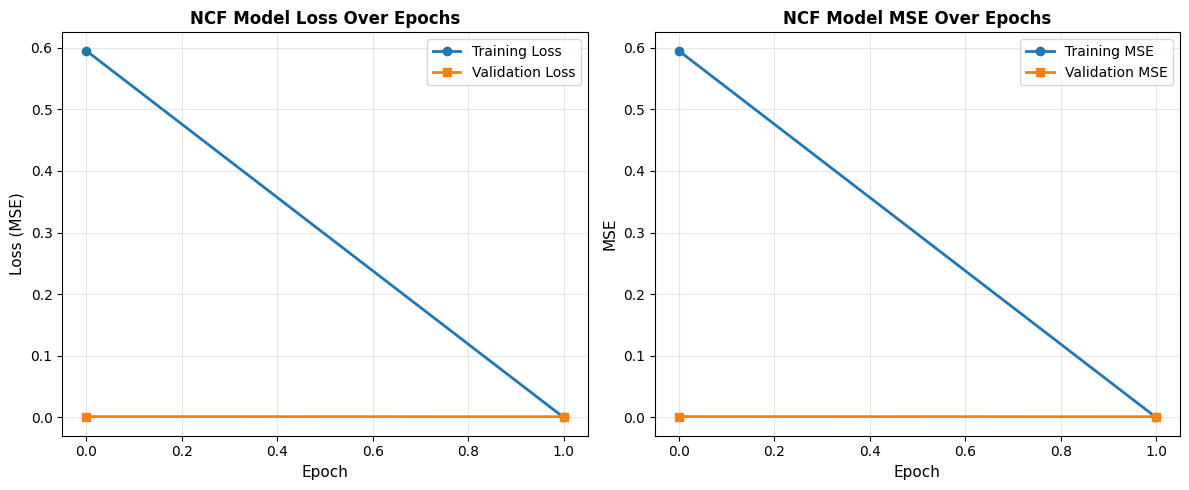


📊 Training Summary:
   Epochs completed: 2
   Final training loss: 0.000018
   Final validation loss: 0.001162
   Best validation loss: 0.001162


In [163]:

# Plot training history

if 'history_ncf' in locals():
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history_ncf.history['loss'], label='Training Loss', linewidth=2, marker='o')
    plt.plot(history_ncf.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
    plt.title('NCF Model Loss Over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch', fontsize=11)
    plt.ylabel('Loss (MSE)', fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    # MSE plot
    plt.subplot(1, 2, 2)
    plt.plot(history_ncf.history['mse'], label='Training MSE', linewidth=2, marker='o')
    plt.plot(history_ncf.history['val_mse'], label='Validation MSE', linewidth=2, marker='s')
    plt.title('NCF Model MSE Over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch', fontsize=11)
    plt.ylabel('MSE', fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Training Summary:")
    print(f"   Epochs completed: {len(history_ncf.history['loss'])}")
    print(f"   Final training loss: {history_ncf.history['loss'][-1]:.6f}")
    print(f"   Final validation loss: {history_ncf.history['val_loss'][-1]:.6f}")
    print(f"   Best validation loss: {min(history_ncf.history['val_loss']):.6f}")
else:
    print("ONNX model loaded, skipping training history plot.")

### content based filtering, makes a Vectorized matrix of all text and then runs cosine between the product names, giving them a value of -1 and 1 using similarities between the items

In [164]:
# ------------------------------------------------------------
# ✅ 5. Content-Based Filtering (TF-IDF on item metadata)
# ------------------------------------------------------------
items_full = items.merge(classes, on="class_id", how="left")

items_full["text"] = items_full["name"] + " " + items_full["class_name"]

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(items_full["text"])

content_sim = cosine_similarity(tfidf_matrix)



In [165]:


# ------------------------------------------------------------
# ✅ 6. Hybrid Scoring Function
# ------------------------------------------------------------
def hybrid_score(user_id, item_id):
    # Collaborative prediction with NCF or Surprise fallback
    if isinstance(cf_model, ort.InferenceSession):
        if user_id in cf_user_id_map and item_id in cf_item_id_map:
            user_idx = np.array([cf_user_id_map[user_id]], dtype=np.int32)
            item_idx = np.array([cf_item_id_map[item_id]], dtype=np.int32)
            ort_inputs = {cf_model.get_inputs()[0].name: user_idx, cf_model.get_inputs()[1].name: item_idx}
            pred = cf_model.run(None, ort_inputs)[0][0, 0]
            cf_score = np.clip(pred, 1.0, 3.0) / 3.0
        else:
            cf_score = 0.0
    elif hasattr(cf_model, "predict") and hasattr(cf_model.predict, "__call__") and "tf" in globals() and isinstance(cf_model, tf.keras.Model):
        if user_id in cf_user_id_map and item_id in cf_item_id_map:
            user_idx = np.array([cf_user_id_map[user_id]])
            item_idx = np.array([cf_item_id_map[item_id]])
            pred = cf_model.predict([user_idx, item_idx], verbose=0)[0, 0]
            cf_score = np.clip(pred, 1.0, 3.0) / 3.0
        else:
            cf_score = 0.0
    else:
        cf_score = cf_model.predict(user_id, item_id).est / 3

    # Content-based similarity
    idx_item = items_full.index[items_full["item_id"] == item_id][0]

    favs = favorites[favorites["user_id"] == user_id]["item_id"].tolist()

    if favs:
        fav_indices = [
            items_full.index[items_full["item_id"] == f][0]
            for f in favs if f in items_full["item_id"].values
        ]
        content_score = content_sim[idx_item][fav_indices].mean()
    else:
        content_score = 0

    # Weighted hybrid
    return 0.6 * cf_score + 0.4 * content_score

In [166]:

# ------------------------------------------------------------
# ✅ 7. Generate Top‑N recommendations for a user (VECTORIZED)
# ------------------------------------------------------------
def recommend_top_n(user_id, N=5):
    """Fast vectorized batch prediction for top-N recommendations."""
    
    # Get all items
    all_items = items_full["item_id"].values
    all_item_names = items_full["name"].values
    
    # Batch predict collaborative scores
    if user_id in cf_user_id_map:
        if isinstance(cf_model, ort.InferenceSession):
            user_idx = np.full(len(all_items), cf_user_id_map[user_id], dtype=np.int32).reshape(-1, 1)
            item_indices = np.array([cf_item_id_map.get(iid, 0) for iid in all_items], dtype=np.int32).reshape(-1, 1)
            ort_inputs = {cf_model.get_inputs()[0].name: user_idx, cf_model.get_inputs()[1].name: item_indices}
            batch_preds = cf_model.run(None, ort_inputs)[0]
            cf_scores = np.clip(batch_preds.flatten(), 1.0, 3.0) / 3.0
        elif isinstance(cf_model, tf.keras.Model):
            user_idx = np.full(len(all_items), cf_user_id_map[user_id], dtype=np.int32)
            item_indices = np.array([cf_item_id_map.get(iid, 0) for iid in all_items], dtype=np.int32)
            
            # Single batch prediction instead of looping (with optimized batch size)
            batch_preds = cf_model.predict([user_idx, item_indices], verbose=0, batch_size=256)
            cf_scores = np.clip(batch_preds.flatten(), 1.0, 3.0) / 3.0
        else:
            cf_scores = np.array([0.0] * len(all_items))
    else:
        cf_scores = np.array([0.0] * len(all_items))
    
    # Batch content-based scoring
    user_favs = favorites[favorites["user_id"] == user_id]["item_id"].tolist()
    
    if user_favs:
        fav_indices = [
            items_full.index[items_full["item_id"] == f][0]
            for f in user_favs if f in items_full["item_id"].values
        ]
        # Vectorized content similarity: mean across favorite items for all items at once
        content_scores = content_sim[:, fav_indices].mean(axis=1)
    else:
        content_scores = np.zeros(len(all_items))
    
    # Combine scores
    hybrid_scores = 0.6 * cf_scores + 0.4 * content_scores
    
    # Get top N
    top_indices = np.argsort(hybrid_scores)[::-1][:N]
    
    results = [
        (all_items[i], all_item_names[i], hybrid_scores[i])
        for i in top_indices
    ]
    
    return results


In [167]:
# ------------------------------------------------------------
# ✅ 8. Example Usage
# ------------------------------------------------------------
print("✅ Top 5 recommendations for user 501:")
print(recommend_top_n(501, 5))

print("\n✅ Top 5 recommendations for user 502:")
print(recommend_top_n(502, 5))


✅ Top 5 recommendations for user 501:
[(4308, 'Sneakers White v288', 0.6641009693707897), (1383, 'Sneakers White v93', 0.6617907090688192), (6078, 'Sneakers White v406', 0.6617532589989676), (2258, 'Winter Coat v151', 0.6529740663855883), (1613, 'Winter Coat v108', 0.6521869802755215)]

✅ Top 5 recommendations for user 502:
[(6896, 'High-Top Sneakers v460', 0.6655521927881498), (2907, 'Slip-On Shoes v194', 0.6548592990345925), (702, 'Slip-On Shoes v47', 0.6547265224817727), (2786, 'High-Top Sneakers v186', 0.6546442211208188), (3612, 'Slip-On Shoes v241', 0.6543547402389083)]
